# Credit Card Lead Prediction for Target Customer


## Objective:

A bank aims to enhance its credit card marketing strategy by targeting potential customers who are likely to show interest in a credit card offer. To achieve this, the bank intends to develop a predictive model that identifies which customers are most likely to respond positively to the credit card offer.

## Business Problem:

The bank needs to optimize its marketing efforts by focusing on customers who are predicted to have a high probability of showing interest in the credit card offer. By leveraging historical customer data, the goal is to build a machine learning model that can accurately predict whether a given customer will respond positively to the offer. This will enable the bank to:

- **Improve Targeting Efficiency:** Allocate marketing resources more effectively by targeting customers with a higher likelihood of interest.
- **Increase Conversion Rates:** Enhance the conversion rate of credit card offers by reaching out to the most promising prospects.
- **Optimize Marketing Costs:** Reduce marketing costs by minimizing efforts on customers with a low probability of responding.

## Data:

The dataset includes customer information such as demographic details, financial status, existing banking relationships, and previous interactions with credit card offers. Key features include:

- **Cust_ID:** Unique identifier for each customer.
- **Gender:** Gender of the customer (Male/Female).
- **Month_Income:** Monthly income of the customer.
- **Age:** Age of the customer.
- **Region_Code:** Geographic region code.
- **Occupation:** Type of occupation (e.g., Salaried, Self-Employed, Business, Student).
- **Credit_Score:** Customer's credit score.
- **Loan_Status:** Whether the customer has any active loans (Yes/No).
- **Existing_Credit_Cards:** Number of credit cards the customer already has.
- **Avg_Account_Balance:** Average balance maintained by the customer in their account.
- **Account_Category:** Categorization based on account balance (e.g., Low, Medium, High and Privilege).
- **Tenure_with_Bank:** Number of years the customer has been with the bank.
- **Lead_Outcome:** Whether the customer showed interest in the credit card offer (Yes/No).

## Goal:

Develop a machine learning model to predict the `Lead_Outcome` based on the provided features, enabling the bank to effectively identify and target customers who are most likely to be interested in a credit card offer.

# Step 1: Import necessary libraries

In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Step 2: Data Gathering and Exploration

In [3]:
# Load the dataset
import pandas as pd

data = pd.read_csv('bank_customer_data.csv')

In [4]:
# Check the data structure 
data.shape

(105000, 13)

In [5]:
# Data Exploration
print("First few rows of the dataset:")
data.head()

First few rows of the dataset:


,ID,Gender,Month_Income,Age,Region_Code,Occupation,Credit_Score,Loan_Status,Existing_Credit_Cards,Avg_Account_Balance,Account_Category,Tenure_with_Bank,Lead_Outcome
0,VBENBARO,Male,96345,29,254,Other,623,Yes,4,742366,X1,2,No
1,CCMEWNKY,Male,85640,43,268,Other,629,NaN,0,925537,X2,1,No
2,VK3KGA9M,Male,96345,31,270,Salaried,357,No,0,215949,X1,1,No
3,TT8RPZVC,Male,85640,29,272,Other,356,No,0,868070,X1,3,No
4,SHQZEYTZ,Female,42820,29,270,Other,572,No,0,657087,X1,3,No


In [6]:
print("\nDataset information:")
data.info()


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   ID                     105000 non-null  str  
 1   Gender                 105000 non-null  str  
 2   Month_Income           105000 non-null  int64
 3   Age                    105000 non-null  int64
 4   Region_Code            105000 non-null  int64
 5   Occupation             105000 non-null  str  
 6   Credit_Score           105000 non-null  int64
 7   Loan_Status            92511 non-null   str  
 8   Existing_Credit_Cards  105000 non-null  int64
 9   Avg_Account_Balance    105000 non-null  int64
 10  Account_Category       105000 non-null  str  
 11  Tenure_with_Bank       105000 non-null  int64
 12  Lead_Outcome           105000 non-null  str  
dtypes: int64(7), str(6)
memory usage: 10.4 MB


# Step 3: Data Cleaning

In [7]:
# Handle missing values and encode categorical variables

#Check Null or mission values
data.isna().sum()

ID                           0
Gender                       0
Month_Income                 0
Age                          0
Region_Code                  0
Occupation                   0
Credit_Score                 0
Loan_Status              12489
Existing_Credit_Cards        0
Avg_Account_Balance          0
Account_Category             0
Tenure_with_Bank             0
Lead_Outcome                 0
dtype: int64

In [8]:
# Drop or fill missing values
data.dropna(inplace=True)  # Example: drop rows with missing values

In [9]:
data.info()

<class 'pandas.DataFrame'>
Index: 92511 entries, 0 to 104998
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   ID                     92511 non-null  str  
 1   Gender                 92511 non-null  str  
 2   Month_Income           92511 non-null  int64
 3   Age                    92511 non-null  int64
 4   Region_Code            92511 non-null  int64
 5   Occupation             92511 non-null  str  
 6   Credit_Score           92511 non-null  int64
 7   Loan_Status            92511 non-null  str  
 8   Existing_Credit_Cards  92511 non-null  int64
 9   Avg_Account_Balance    92511 non-null  int64
 10  Account_Category       92511 non-null  str  
 11  Tenure_with_Bank       92511 non-null  int64
 12  Lead_Outcome           92511 non-null  str  
dtypes: int64(7), str(6)
memory usage: 9.9 MB


# Step 4: Exploratory Data Analysis (EDA)

In [10]:
print("\nStatistical summary of the dataset")
data.describe()


Statistical summary of the dataset


,Month_Income,Age,Region_Code,Credit_Score,Existing_Credit_Cards,Avg_Account_Balance,Tenure_with_Bank
count,92511.000000,92511.000000,92511.000000,92511.000000,92511.000000,9.251100e+04,92511.000000
mean,100725.972479,42.824032,269.623753,598.494730,1.367437,1.120815e+06,5.660808
std,45173.814450,14.889506,10.910321,179.960889,2.208557,8.638349e+05,4.065430
min,42820.000000,24.000000,250.000000,300.000000,0.000000,2.259700e+04,1.000000
25%,64230.000000,29.000000,260.000000,441.000000,0.000000,5.946170e+05,3.000000
50%,94725.000000,41.000000,269.000000,583.000000,0.000000,8.827460e+05,5.000000
75%,115775.000000,53.000000,280.000000,767.000000,3.000000,1.353307e+06,8.000000
max,210500.000000,85.000000,284.000000,900.000000,7.000000,9.908858e+06,15.000000


In [11]:
# Set the style for seaborn plots
import seaborn as sns
sns.set(style="whitegrid")

# Function to plot distributions
def plot_distribution(column):
    plt.figure(figsize=(12, 6))
    if data[column].dtype == 'object':
        sns.countplot(x=column, data=data, palette='viridis')
        plt.title(f'Distribution of {column}')
    else:
        sns.histplot(data[column], bins=30, kde=True, color='skyblue')
        plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# Function to plot boxplots
def plot_boxplot(column):
    plt.figure(figsize=(12, 6))
    if data[column].dtype != 'object':
        sns.boxplot(y=data[column], color='lightcoral')
        plt.title(f'Boxplot of {column}')
        plt.ylabel(column)
    else:
        print(f'{column} is categorical. Boxplot not applicable.')
    plt.show()

# Function to plot count plot by target
def plot_by_target(column, target_column='Lead_Outcome'):
    plt.figure(figsize=(12, 6))
    if data[column].dtype == 'object':
        sns.countplot(x=column, hue=target_column, data=data, palette='Set2')
        plt.title(f'{column} Distribution by {target_column}')
    else:
        sns.boxplot(x=target_column, y=column, data=data, palette='Set2')
        plt.title(f'{column} Distribution by {target_column}')
    plt.xlabel(target_column)
    plt.ylabel('Count' if data[column].dtype == 'object' else column)
    plt.show()

### Let's explore each column to understand them

In [16]:
import matplotlib.pyplot as plt
# plot_distribution('Gender')

# plot_by_target('Gender')

### 1. Gender

<Axes: xlabel='Gender', ylabel='count'>

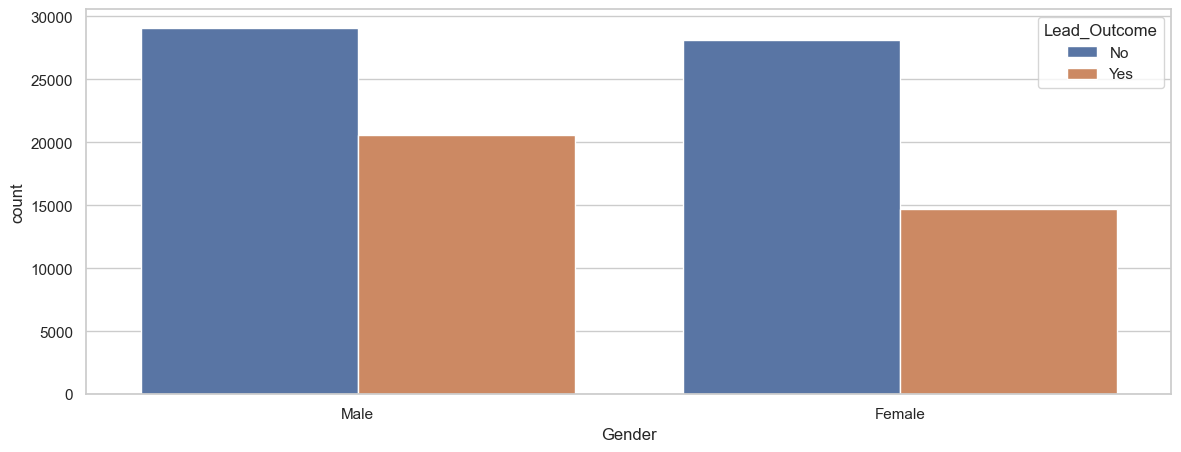

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.countplot(data=data,
              x='Gender',
              hue='Lead_Outcome')

### 2. Month_Income

C:\Users\WELCOME\AppData\Local\Temp\ipykernel_6348\546650799.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_column, y=column, data=data, palette='Set2')


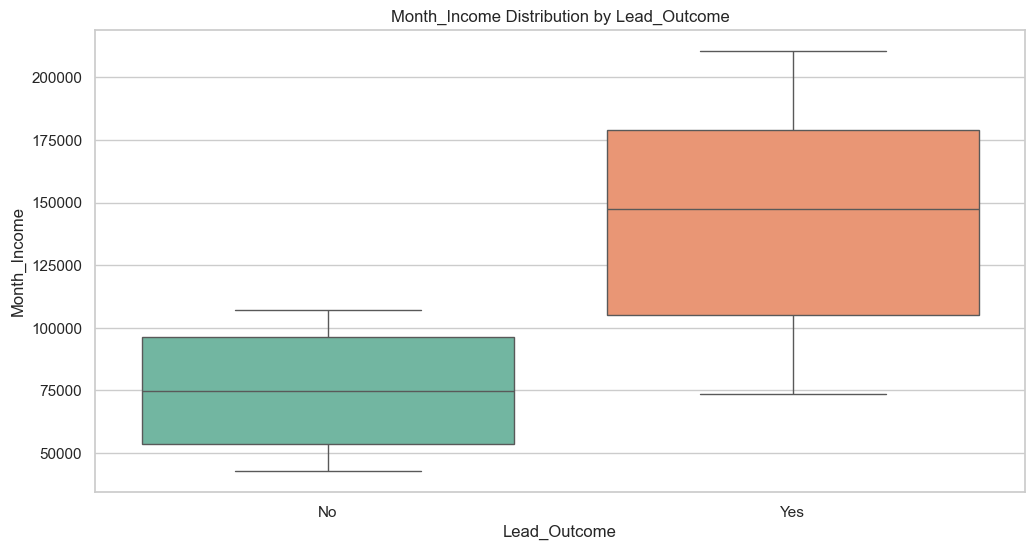

In [13]:
# plot_distribution('Month_Income')
# plot_boxplot('Month_Income')
plot_by_target('Month_Income')

### 3. Age

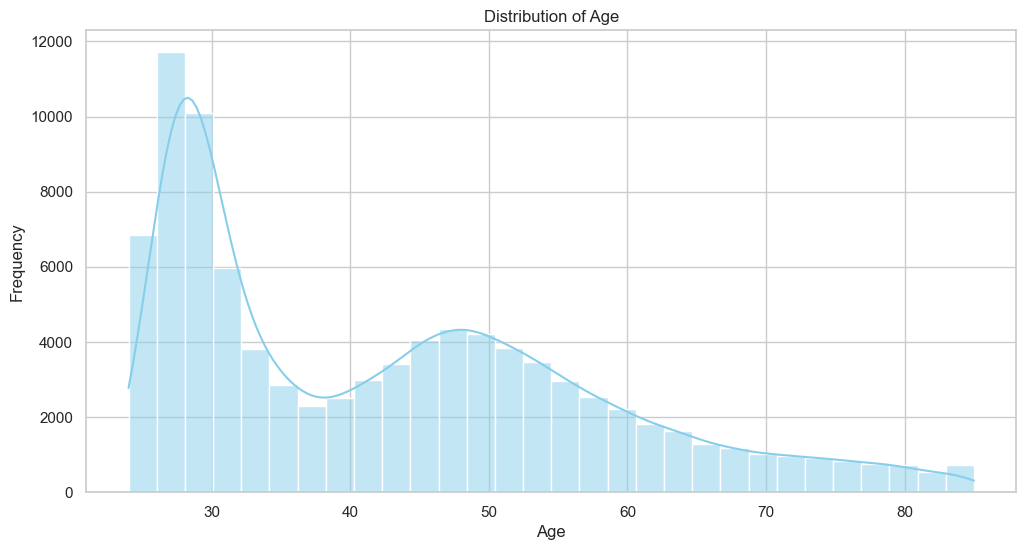

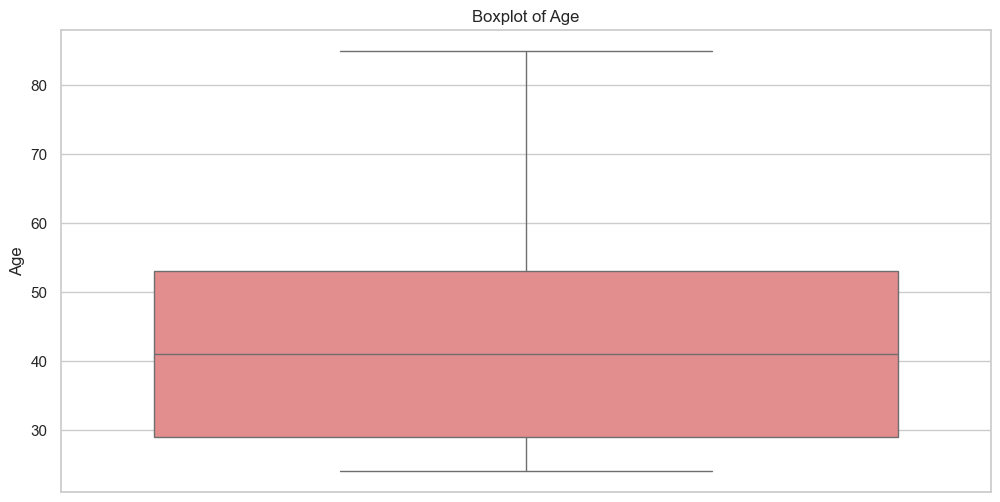

C:\Users\WELCOME\AppData\Local\Temp\ipykernel_6348\546650799.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_column, y=column, data=data, palette='Set2')


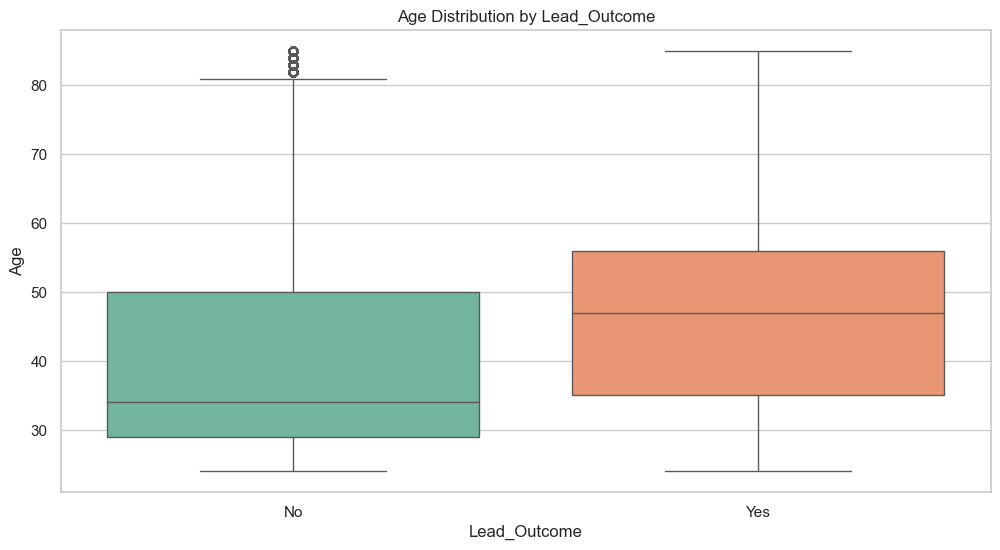

In [14]:
plot_distribution('Age')
plot_boxplot('Age')
plot_by_target('Age')

### 4. Region_Code

<Axes: xlabel='Region_Code', ylabel='count'>

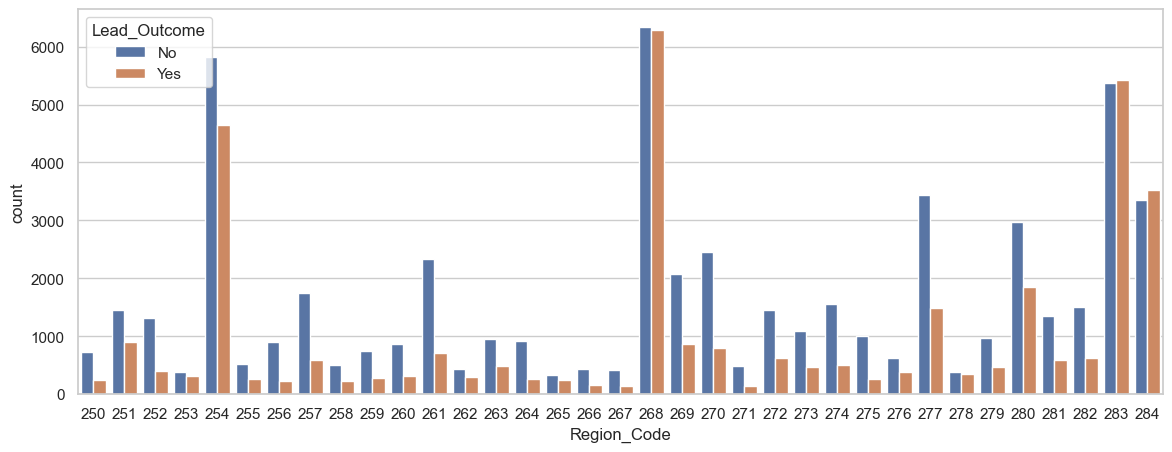

In [15]:
# plot_distribution('Region_Code')
# plot_by_target('Region_Code')
fig, ax = plt.subplots(figsize=(14, 5))
sns.countplot(data=data,
              x='Region_Code',
              hue='Lead_Outcome')

### 5. Occupation

<Axes: xlabel='Occupation', ylabel='count'>

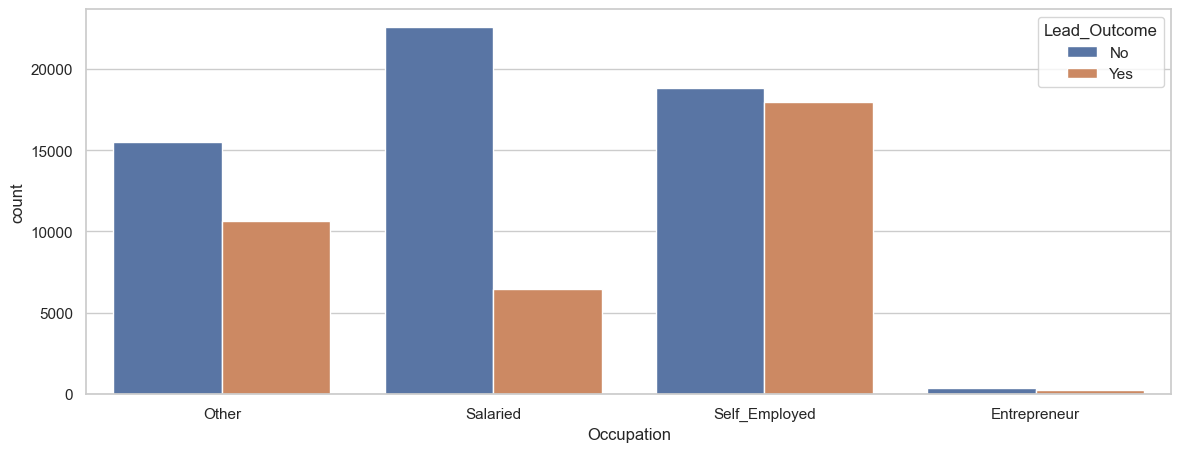

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.countplot(data=data,
              x='Occupation',
              hue='Lead_Outcome')

In [22]:
# plot_distribution('Occupation')
# plot_by_target('Occupation')



### 6. Credit_Score

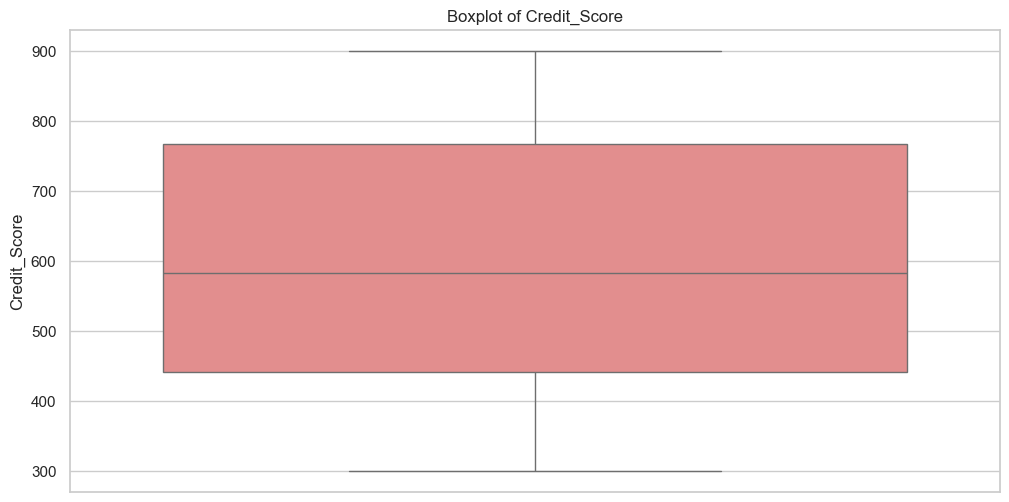

C:\Users\WELCOME\AppData\Local\Temp\ipykernel_8668\546650799.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_column, y=column, data=data, palette='Set2')


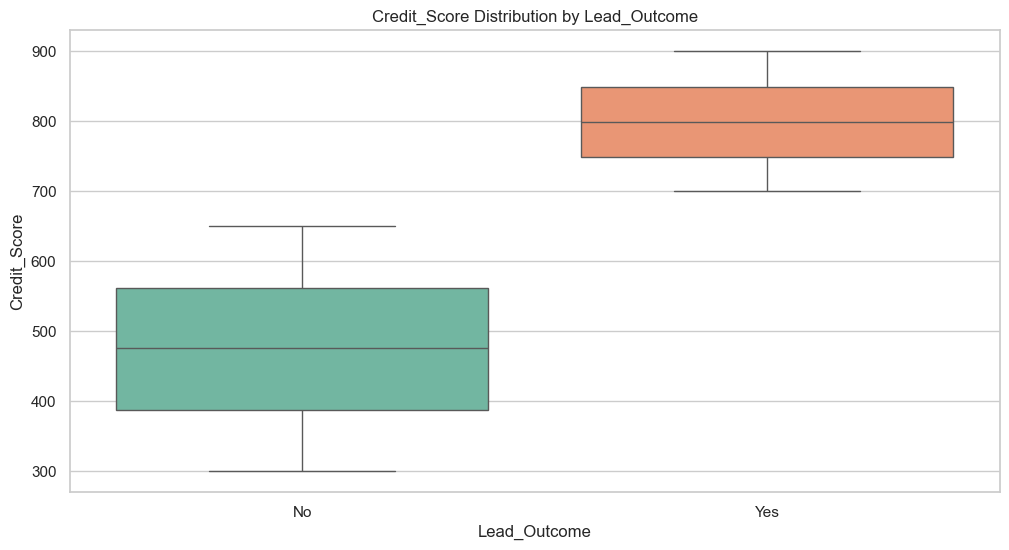

In [23]:
# plot_distribution('Credit_Score')
plot_boxplot('Credit_Score')
plot_by_target('Credit_Score')

### 7. Loan_Status

<Axes: xlabel='Loan_Status', ylabel='count'>

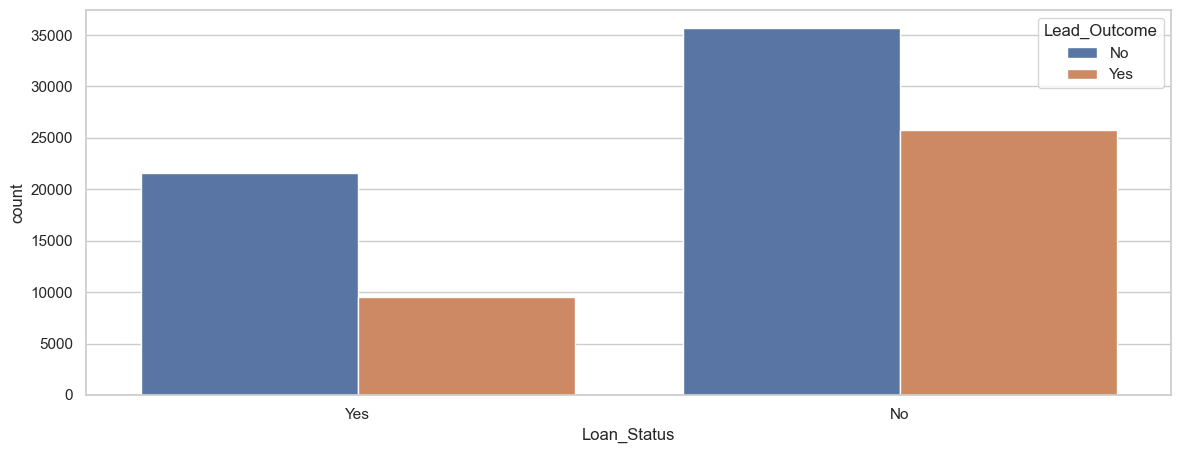

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.countplot(data=data,
              x='Loan_Status',
              hue='Lead_Outcome')

In [25]:
#plot_distribution('Loan_Status')
#plot_by_target('Loan_Status')


### 8. Existing_Credit_Cards

<Axes: xlabel='Existing_Credit_Cards', ylabel='count'>

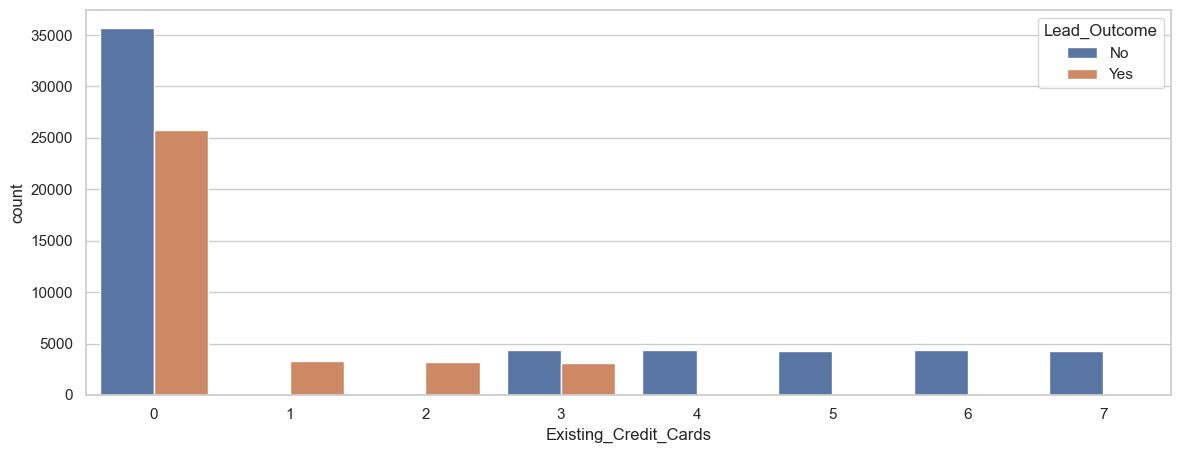

In [26]:
# plot_distribution('Existing_Credit_Cards')
# plot_boxplot('Existing_Credit_Cards')
# plot_by_target('Existing_Credit_Cards')
fig, ax = plt.subplots(figsize=(14, 5))
sns.countplot(data=data,
              x='Existing_Credit_Cards',
              hue='Lead_Outcome')

### 9. Avg_Account_Balance

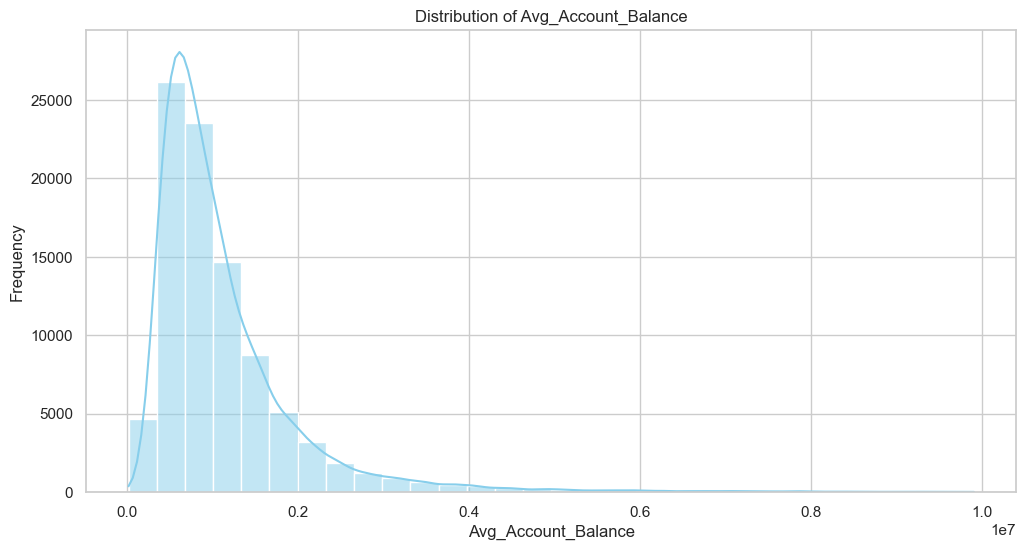

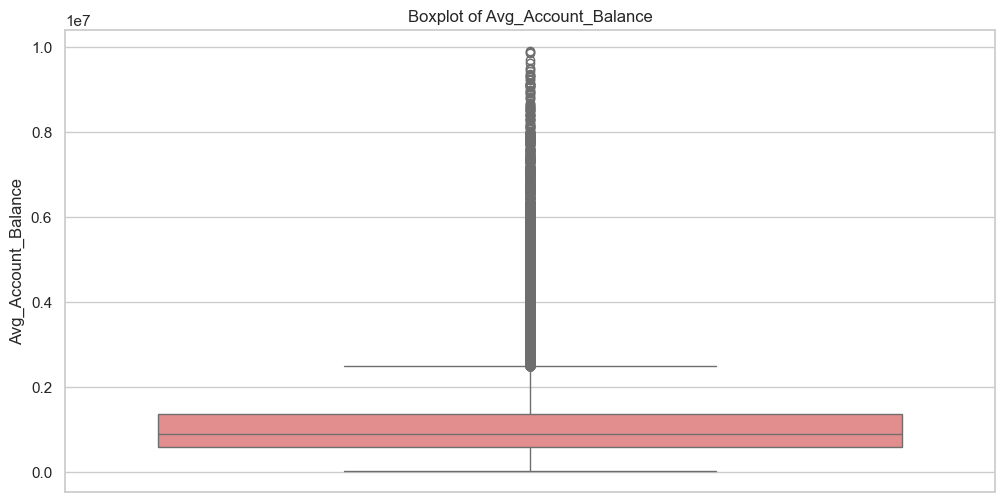

C:\Users\WELCOME\AppData\Local\Temp\ipykernel_8668\546650799.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_column, y=column, data=data, palette='Set2')


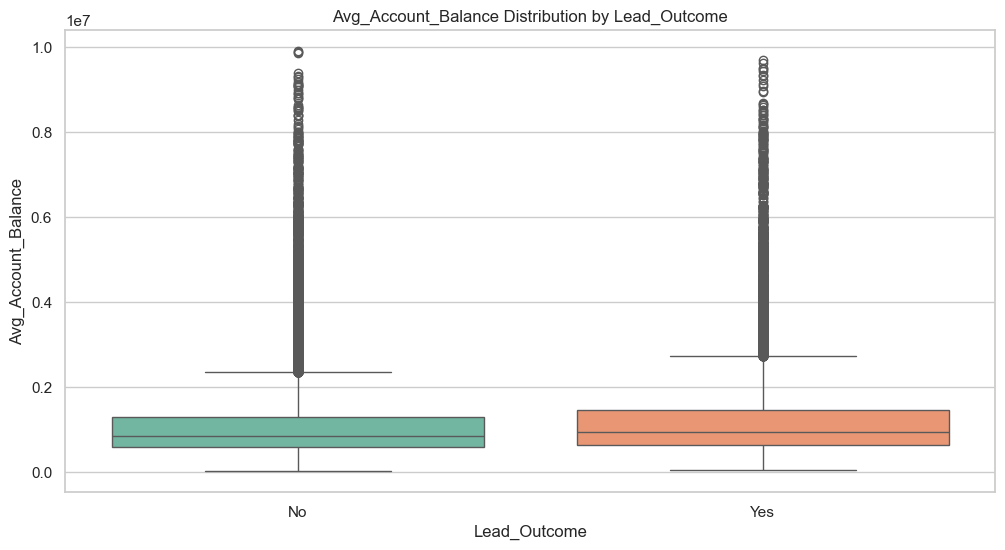

In [27]:
plot_distribution('Avg_Account_Balance')
plot_boxplot('Avg_Account_Balance')
plot_by_target('Avg_Account_Balance')

### 10. Account_Category

<Axes: xlabel='Account_Category', ylabel='count'>

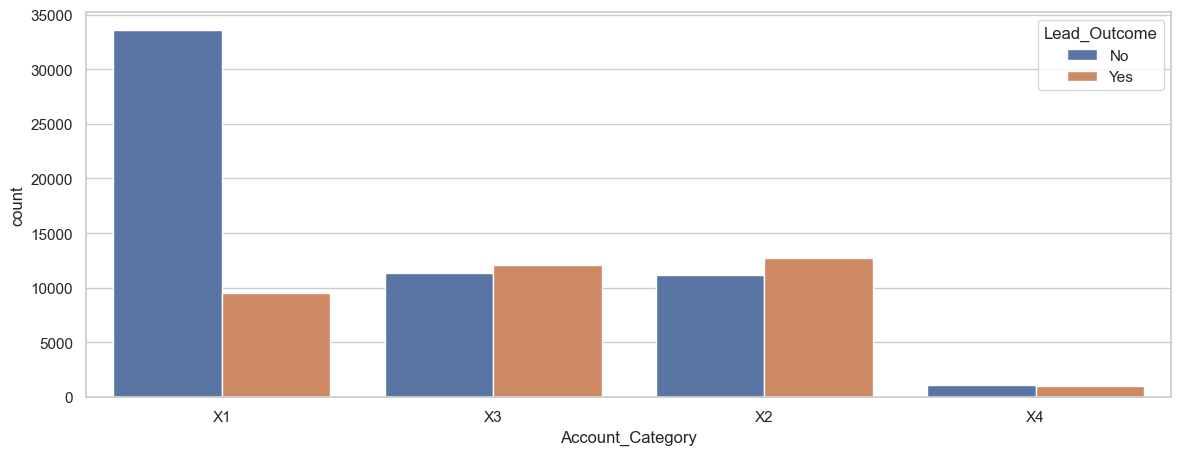

In [28]:
# plot_distribution('Account_Category')
# plot_by_target('Account_Category')
fig, ax = plt.subplots(figsize=(14, 5))
sns.countplot(data=data,
              x='Account_Category',
              hue='Lead_Outcome')

### 11. Tenure_with_Bank

<Axes: xlabel='Tenure_with_Bank', ylabel='count'>

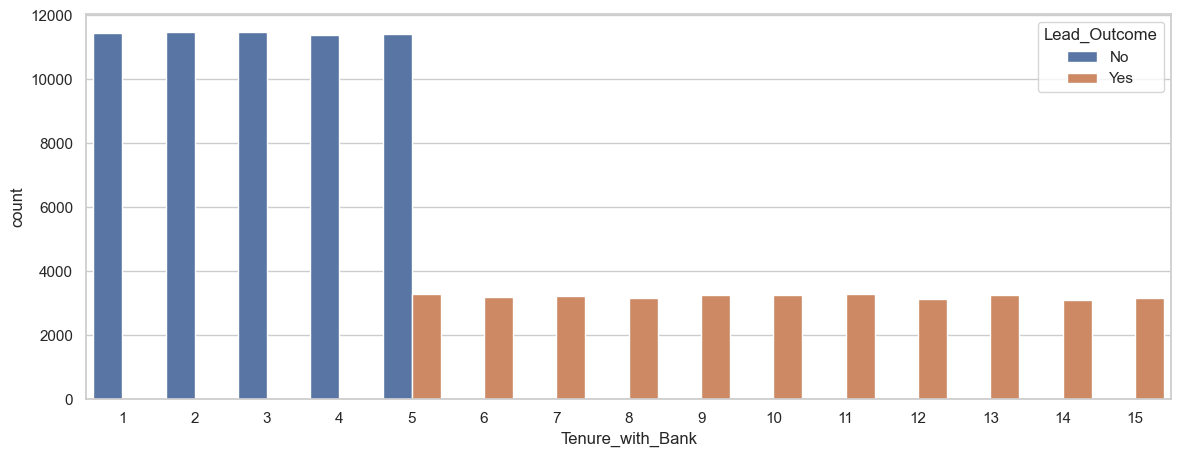

In [29]:
# plot_distribution('Tenure_with_Bank')
# plot_boxplot('Tenure_with_Bank')
# plot_by_target('Tenure_with_Bank')
fig, ax = plt.subplots(figsize=(14, 5))
sns.countplot(data=data,
              x='Tenure_with_Bank',
              hue='Lead_Outcome')

### 12. Lead_Outcome

<Axes: xlabel='Lead_Outcome', ylabel='count'>

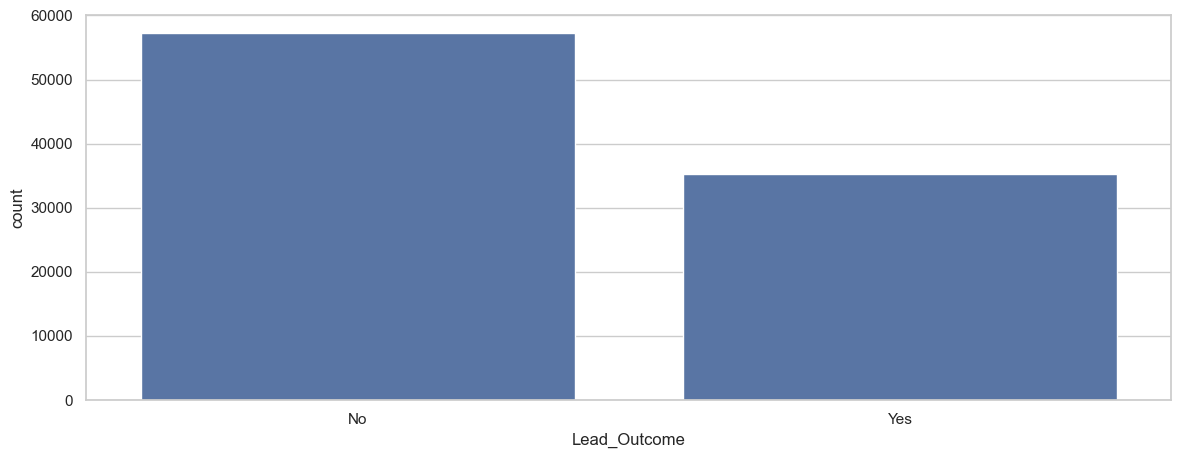

In [30]:
# Lead_Outcome is the target variable, so typically, you don’t need to plot its distribution by itself.
# plot_distribution('Lead_Outcome')
fig, ax = plt.subplots(figsize=(14, 5))
sns.countplot(data=data,
              x='Lead_Outcome')

# Step5 - Data Preprocessing

In [31]:
# Step 1: Drop the "ID" column
from sklearn.preprocessing import LabelEncoder
data = data.drop(columns=['ID','Credit_Score'])

# Step 2: Convert categorical features into numerical values

# Define categorical columns
categorical_columns = ['Gender', 'Occupation', 'Loan_Status', 'Account_Category', 'Lead_Outcome']

# Initialize the LabelEncoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [32]:
data.head()

,Gender,Month_Income,Age,Region_Code,Occupation,Loan_Status,Existing_Credit_Cards,Avg_Account_Balance,Account_Category,Tenure_with_Bank,Lead_Outcome
0,1,96345,29,254,1,1,4,742366,0,2,0
2,1,96345,31,270,2,0,0,215949,0,1,0
3,1,85640,29,272,1,0,0,868070,0,3,0
4,0,42820,29,270,1,0,0,657087,0,3,0
5,1,64230,60,268,3,0,0,4624262,2,5,0


# Step6 - Feature Selection/Engineering

In [33]:
# Feature and target separation
X = data.drop(columns=['Lead_Outcome'])  # feature / predictor
y = data['Lead_Outcome']  # Target - column to be predicted

# Step7 -  Model Selection and Build Models

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize models
models = {
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC()
}

# Fit models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} model trained.')


Random Forest model trained.


C:\Users\WELCOME\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression model trained.
SVM model trained.


In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Function to evaluate and print performance metrics for all models
def evaluate_models(models, X_test, y_test):
    for name, model in models.items():
        print(f'\nPerformance Report for {name}:\n')
        
        # Predict the outcomes
        y_pred = model.predict(X_test)
        
        # Compute and print accuracy
        accuracy = accuracy_score(y_test, y_pred)
        print(f'Accuracy: {accuracy:.4f}')
        
        # Compute and print confusion matrix
        print('Confusion Matrix:')
        print(confusion_matrix(y_test, y_pred))
        
        # Compute and print classification report
        print('Classification Report:')
        print(classification_report(y_test, y_pred))

# Call the function to evaluate models
evaluate_models(models, X_test, y_test) # 27754 - total, Correct predictions = 27669, 27669/27754


Performance Report for Random Forest:

Accuracy: 0.9969
Confusion Matrix:
[[17097     4]
 [   83 10570]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17101
           1       1.00      0.99      1.00     10653

    accuracy                           1.00     27754
   macro avg       1.00      1.00      1.00     27754
weighted avg       1.00      1.00      1.00     27754


Performance Report for Logistic Regression:

Accuracy: 0.8921
Confusion Matrix:
[[15834  1267]
 [ 1729  8924]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     17101
           1       0.88      0.84      0.86     10653

    accuracy                           0.89     27754
   macro avg       0.89      0.88      0.88     27754
weighted avg       0.89      0.89      0.89     27754


Performance Report for SVM:

Accuracy: 0.8789
Confusion Matrix:
[[17077    24]
 [

# Step8 - Model Training (Hyperparameter Tuning)

In [36]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for RandomForest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Grid search for RandomForest
grid_rf = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid_rf, cv=3, scoring='accuracy')
grid_rf.fit(X_train, y_train)
print(f'Best parameters for Random Forest: {grid_rf.best_params_}')

Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


# Step9 - Model Evaluation

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

# Choose the best model from GridSearchCV (if tuning was done) or other models
best_model = grid_rf.best_estimator_ if 'grid_rf' in locals() else models['Random Forest']

# Predictions
y_pred = best_model.predict(X_test)

# Evaluation metrics
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[17101     0]
 [   77 10576]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17101
           1       1.00      0.99      1.00     10653

    accuracy                           1.00     27754
   macro avg       1.00      1.00      1.00     27754
weighted avg       1.00      1.00      1.00     27754



# Step10 - Model Interpretation

In [38]:
importances = best_model.feature_importances_ if hasattr(best_model, 'feature_importances_') else None
if importances is not None:
    feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    print(feature_importances)

                 Feature  Importance
9       Tenure_with_Bank    0.587314
1           Month_Income    0.312928
6  Existing_Credit_Cards    0.047107
8       Account_Category    0.023685
2                    Age    0.012008
7    Avg_Account_Balance    0.004792
5            Loan_Status    0.004043
4             Occupation    0.004011
3            Region_Code    0.003710
0                 Gender    0.000402


# Step 11 - Deployment

In [40]:
#For deployment, you might consider saving the model and using it in a production environment. Here’s an example of saving the model using joblib:
import joblib

# Save the model
joblib.dump(best_model, 'credit_card_lead_prediction_model.pkl')

# Load the model (for prediction later)
loaded_model = joblib.load('credit_card_lead_prediction_model.pkl')

### Steps to Predict Output with New Data After Deploying the Model

- **Load the Trained Model:** First, you need to load the trained model from the file where it was saved.
- **Prepare New Data:** Ensure the new data is preprocessed in the same way as the data used for training the model (e.g., encoding categorical variables, scaling numerical features if needed).
- **Make Predictions:** Use the loaded model to make predictions on the new data.

### 1. Load the Trained Model

In [41]:
import joblib

# Load the model (assuming the model was saved as 'credit_card_lead_prediction_model.pkl')
model = joblib.load('credit_card_lead_prediction_model.pkl')


### 2. Prepare New Data
Assume new_data is a Pandas DataFrame containing the new customer data:

In [42]:
# Example new data (replace this with actual new data)
new_data = pd.DataFrame({
    'Gender': ['Male'],
    'Month_Income': [90000],
    'Age': [35],
    'Region_Code': [283],
    'Occupation': ['Salaried'],
    #'Credit_Score': [350],
    'Loan_Status': ['No'],
    'Existing_Credit_Cards': [2],
    'Avg_Account_Balance': [200000],
    'Account_Category': ['X1'],
    'Tenure_with_Bank': [6]
})

# Preprocess the new data (the same preprocessing steps as the training data)
new_data['Gender'] = new_data['Gender'].map({'Male': 1, 'Female': 0})
new_data['Occupation'] = new_data['Occupation'].map({'Entrepreneur': 1, 'Self-Employed': 2, 'Salaried': 3, 'Other': 4})
new_data['Loan_Status'] = new_data['Loan_Status'].map({'Yes': 1, 'No': 0})
new_data['Account_Category'] = new_data['Account_Category'].map({'X1': 1, 'X2': 2, 'X3': 3,'X4': 4})
#new_data = new_data.drop(columns=['Region_Code'])  # Assuming 'Region_Code' was dropped earlier


In [43]:
new_data

,Gender,Month_Income,Age,Region_Code,Occupation,Loan_Status,Existing_Credit_Cards,Avg_Account_Balance,Account_Category,Tenure_with_Bank
0,1,90000,35,283,3,0,2,200000,1,6


### 3. Make Predictions

In [44]:
# Make predictions
predictions = model.predict(new_data)

# Convert predictions to readable format if needed (e.g., Yes/No)
predictions = ['Yes' if pred == 1 else 'No' for pred in predictions]

# Output the predictions
print(f'Predicted Lead Outcome: {predictions[0]}')

Predicted Lead Outcome: Yes


### Deployment Considerations

- **Deployment Environment:** The model needs to be deployed in an environment where it can be accessed, such as a web server, cloud service, or local application.

- **API Interface:** If deployed in a production environment, the model can be exposed via an API (e.g., Flask, FastAPI) to receive new data and return predictions.

#### The project is now complete. Future steps include integration with live systems and continuous model updates.

I hope this kernal is useful to you to learn how to make machine learning model for predicting preapproved loan.

If find this notebook help you to learn, Please Upvote.

Thank You!!